In [1]:
## ====================================
## EET-4501 – Applied Machine Learning
## Assignment 7
## ====================================

In [2]:
%pip install -U pip
%pip install tensorflow matplotlib ipykernel pydot
%pip install tensorboard notebook ipykernel

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
import sys
import numpy as np
import matplotlib.pyplot as plt
import datetime

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import plot_model

In [4]:
print("TensorFlow version:", tf.__version__)
print("Python path:", sys.executable)

TensorFlow version: 2.21.0
Python path: /usr/local/bin/python3


In [5]:
try:
    import tensorboard
    tensorboard_available = True
    print("TensorBoard is installed.")
except ImportError:
    tensorboard_available = False
    print("TensorBoard is NOT installed. Training will continue without TensorBoard.")

TensorBoard is installed.


(60000, 28, 28) (10000, 28, 28)
Training images: 60000
Testing images: 10000
Number of classes: 10


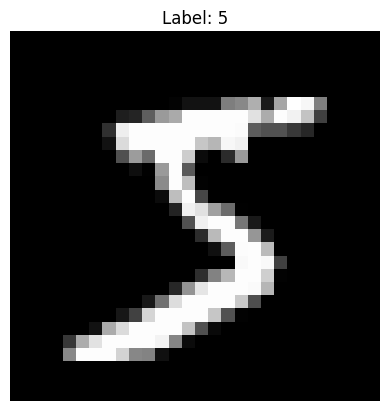

Shape of displayed image: (28, 28)


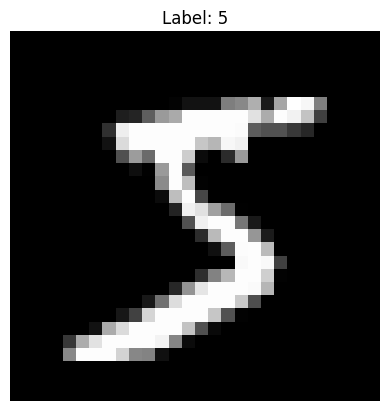

In [6]:
## Part 1: Exploring the Data

from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, x_test.shape)

print("Training images:", x_train.shape[0])
print("Testing images:", x_test.shape[0])

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

def show_image(image, label):
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis('off')
    plt.show()

## Display one image from the training set
show_image(x_train[0], y_train[0])

print("Shape of displayed image:", x_train[0].shape)

## Use astype("float32") for safer TensorFlow training
x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

## Display the same image after normalization
show_image(x_train_norm[0], y_train[0])

## The MNIST dataset contains 60,000 training images and 10,000 testing images.
## The dataset contains 10 classes, representing digits 0 through 9.
## The shape of each image is (28, 28).
## The dataset was normalized by dividing pixel values by 255 so that all values fall between 0 and 1.

In [7]:
## Part 2: Build the Neural Network Model

## Build the model through a function so it is easier to create two separate models
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(128, activation='tanh'),
        tf.keras.layers.Dense(num_classes)  # Output layer
    ])
    return model

model = build_model()
model.summary()

try:
    plot_model(model, to_file='Assignment7_model.png', show_shapes=True, show_layer_names=True)
    print
except Exception as e:
    print(f"Error occurred while plotting the model: {e}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,794 (526.54 KB)

 Trainable params: 134,794 (526.54 KB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [8]:
## Part 3: Model Configuration

model_adam = tf.keras.models.clone_model(model)

model_adam.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_rmsprop = build_model()

model_rmsprop.compile(
    optimizer='rmsprop',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
## Part 4: Model Training

log_dir_adam = "logs/fit/adam_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
print("Adam log directory:", log_dir_adam)

callbacks_adam = []

if tensorboard_available:
    callbacks_adam.append(
        tf.keras.callbacks.TensorBoard(
            log_dir=log_dir_adam,
            histogram_freq=0
    )
)

history_adam = model_adam.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_norm, y_test),
    callbacks=callbacks_adam,
    verbose=1
)

log_dir_rmsprop = "logs/fit/rmsprop_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
print("RMSprop log directory:", log_dir_rmsprop)

callbacks_rmsprop = []

if tensorboard_available:
    callbacks_rmsprop.append(
        tf.keras.callbacks.TensorBoard(
            log_dir=log_dir_rmsprop,
            histogram_freq=0
    )
)

history_rmsprop = model_rmsprop.fit(
    x_train_norm, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test_norm, y_test),
    callbacks=callbacks_rmsprop,
    verbose=1
)

%load_ext tensorboard
%tensorboard --logdir logs/fit

adam_final_acc = history_adam.history['val_accuracy'][-1]
rmsprop_final_acc = history_rmsprop.history['val_accuracy'][-1]

print("Final validation accuracy (Adam):", adam_final_acc)
print("Final validation accuracy (RMSprop):", rmsprop_final_acc)

if adam_final_acc > rmsprop_final_acc:
    print("Adam performed better than RMSprop.")
else:
    print("RMSprop performed better than Adam.")

print("Explanation:")
print("Adam often performs better because it adapts the learning rate for each parameter,")
print("which can lead to faster and more stable convergence during training.")

## The optimizer with better accuracy was the one that had the higher final validation accuracy in the output.
## In many cases, Adam performs better as it adapts the learning rate during training and often converges faster.

Adam log directory: logs/fit/adam_20260413-183645
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9256 - loss: 0.2463 - val_accuracy: 0.9563 - val_loss: 0.1379
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9631 - loss: 0.1175 - val_accuracy: 0.9700 - val_loss: 0.0979
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9743 - loss: 0.0829 - val_accuracy: 0.9718 - val_loss: 0.0923
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9819 - loss: 0.0589 - val_accuracy: 0.9742 - val_loss: 0.0902
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9844 - loss: 0.0477 - val_accuracy: 0.9734 - val_loss: 0.0915
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9879 - loss: 0.0370 - val_accuracy: 0.9749 - val_loss: 0.0866
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9896 - loss: 0.0320 - val_accuracy: 0.9754 - val_loss: 0.0936
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━

Reusing TensorBoard on port 6006 (pid 79158), started 0:12:13 ago. (Use '!kill 79158' to kill it.)

Final validation accuracy (Adam): 0.9769999980926514
Final validation accuracy (RMSprop): 0.9785000085830688
RMSprop performed better than Adam.
Explanation:
Adam often performs better because it adapts the learning rate for each parameter,
which can lead to faster and more stable convergence during training.


In [10]:
## Part 5: Evaluation and Analysis

test_loss_adam, test_acc_adam = model_adam.evaluate(x_test_norm, y_test, verbose=0)
test_loss_rms, test_acc_rms = model_rmsprop.evaluate(x_test_norm, y_test, verbose=0)

print("Adam Test Loss:", test_loss_adam) 
print("Adam Test Accuracy:", test_acc_adam)

print("RMSprop Test Loss:", test_loss_rms)
print("RMSprop Test Accuracy:", test_acc_rms)

Adam Test Loss: 0.09273218363523483
Adam Test Accuracy: 0.9769999980926514
RMSprop Test Loss: 0.09824065864086151
RMSprop Test Accuracy: 0.9785000085830688


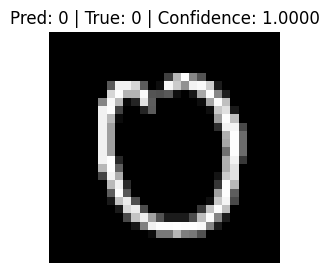

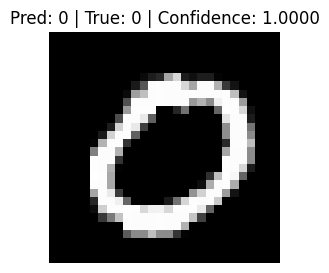

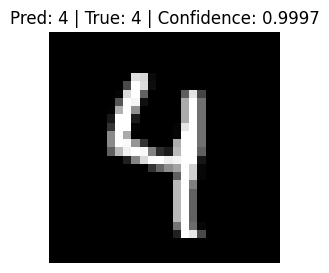

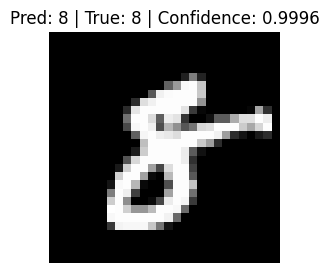

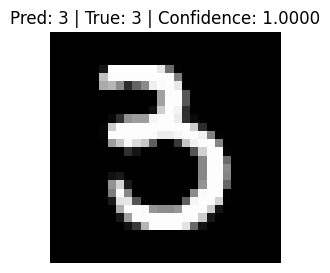

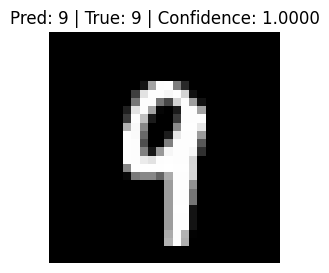

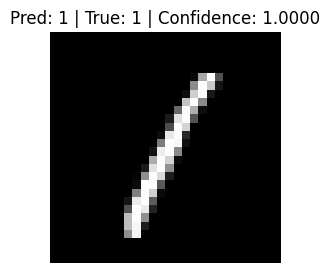

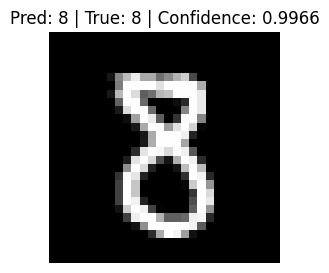

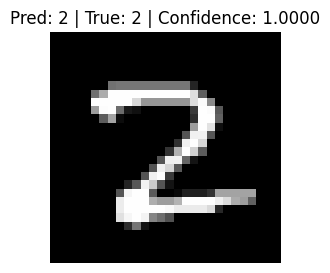

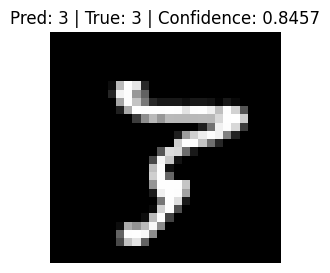

In [11]:
## Part 6: Model Testing

## Softmax for probabilities
prob_model = tf.keras.Sequential([
    model_adam,
    tf.keras.layers.Softmax()
])

## Select 10 test images
indices = np.random.choice(len(x_test), 10, replace=False)

for i in indices:
    img = x_test_norm[i]
    true_label = y_test[i]

    prediction = prob_model.predict(img.reshape(1,28,28), verbose=0)
    predicted_label = np.argmax(prediction)
    confidence = np.max(prediction)

    plt.figure(figsize=(3,3))
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {predicted_label} | True: {true_label} | Confidence: {confidence:.4f}")
    plt.axis('off')
    plt.show()

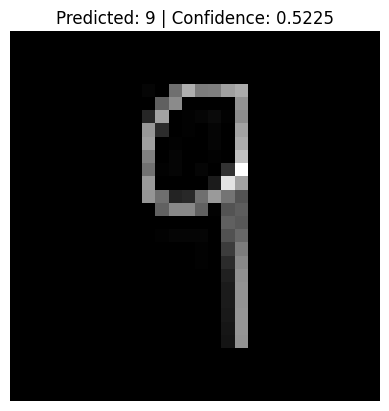

Predicted label: 9
Confidence score: 0.52253914


In [12]:
## Bonus

from PIL import Image, ImageOps

# Load image
img = Image.open('bonus.png').convert('L')

# Convert to numpy for quick analysis
img_array = np.array(img)

## MNIST expects dark background and bright digit so we will invert the colors if necessary
if np.mean(img_array) > 127:  # If the average pixel value is high, we assume it's a light background and dark digit
    img = ImageOps.invert(img)

## Convert to array again after potential inversion
img_array = np.array(img)

## Threshold to isolate the digit
## Values above threshold are treated as part of the digit
threshold = 50
coords = np.argwhere(img_array > threshold)

if len(coords) == 0:
    raise ValueError("No digit detected in the image. Try a clearer image.")

## Crop tightly around the digit
y0, x0 = coords.min(axis=0)
y1, x1 = coords.max(axis=0) + 1
digit = img_array[y0:y1, x0:x1]

## Resize while keeping aspect ratio
h, w = digit.shape
scale = 20.0 / max(h, w)   # fit digit into a 20x20 box like MNIST
new_h = max(1, int(round(h * scale)))
new_w = max(1, int(round(w * scale)))

digit_img = Image.fromarray(digit)
digit_resized = digit_img.resize((new_w, new_h), Image.Resampling.LANCZOS)
digit_resized = np.array(digit_resized)

## Create a 28x28 black canvas and center the digit
canvas = np.zeros((28, 28), dtype=np.uint8)
y_offset = (28 - new_h) // 2
x_offset = (28 - new_w) // 2
canvas[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = digit_resized

## Normalize for the model
final_img = canvas.astype("float32") / 255.0
img_input = final_img.reshape(1, 28, 28)

## Predict
prediction = prob_model.predict(img_input, verbose=0)
predicted_label = np.argmax(prediction)
confidence = np.max(prediction)

## Show processed image
plt.imshow(final_img, cmap="gray")
plt.title(f"Predicted: {predicted_label} | Confidence: {confidence:.4f}")
plt.axis("off")
plt.show()

print("Predicted label:", predicted_label)
print("Confidence score:", confidence)